In [2]:
import os
import torch
from matplotlib import pyplot as plt
import numpy as np
import cv2

In [3]:
model = torch.hub.load('ultralytics/yolov5', 'custom', path='yolov5/runs/train/exp/weights/last.pt', force_reload=True)

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to C:\Users\atharva_nimbalkar/.cache\torch\hub\master.zip
requirements: YOLOv5 requirements "gitpython" "wheel>=0.38.0" not found, attempting AutoUpdate...

requirements: 2 packages updated per C:\Users\atharva_nimbalkar\.cache\torch\hub\ultralytics_yolov5_master\requirements.txt
requirements:  Restart runtime or rerun command for updates to take effect

YOLOv5  2023-2-23 Python-3.9.16 torch-1.13.1 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)

Fusing layers... 
Model summary: 157 layers, 7053277 parameters, 0 gradients
Adding AutoShape... 


In [4]:
img = os.path.join('data', 'images', 'cotton.000dcdc2-1249-41ea-9ea5-776a376505ed.jpeg')

In [5]:
results = model(img)

In [6]:
results.print()

image 1/1: 208x242 (no detections)
Speed: 21.7ms pre-process, 1331.6ms inference, 7.1ms NMS per image at shape (1, 3, 576, 640)


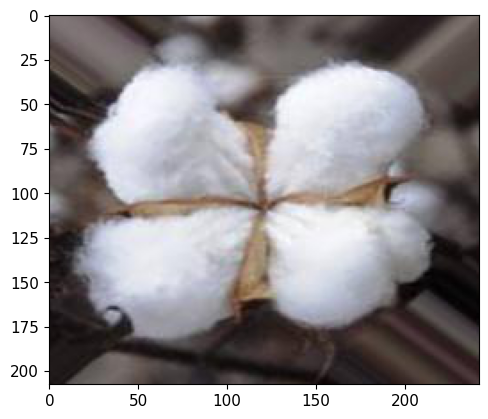

In [7]:
%matplotlib inline 
plt.imshow(np.squeeze(results.render()))
plt.show()

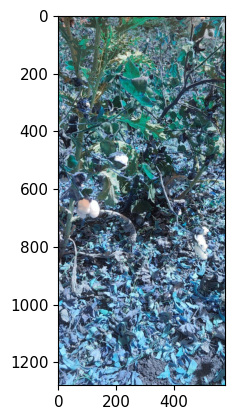

image 1/1: 1280x576 (no detections)
Speed: 2.7ms pre-process, 37.5ms inference, 1.0ms NMS per image at shape (1, 3, 640, 288)


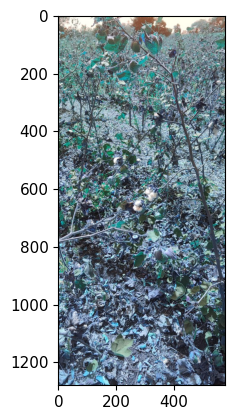

image 1/1: 1280x576 (no detections)
Speed: 2.0ms pre-process, 37.0ms inference, 0.0ms NMS per image at shape (1, 3, 640, 288)


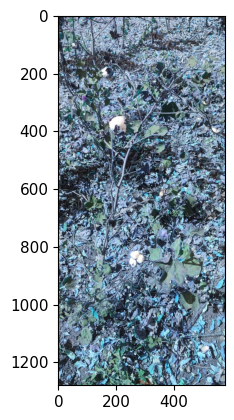

image 1/1: 1280x576 (no detections)
Speed: 2.0ms pre-process, 44.5ms inference, 1.0ms NMS per image at shape (1, 3, 640, 288)


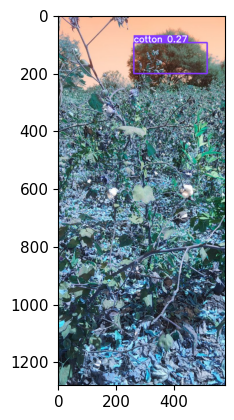

image 1/1: 1280x576 1 cotton
Speed: 1.0ms pre-process, 37.5ms inference, 28.9ms NMS per image at shape (1, 3, 640, 288)


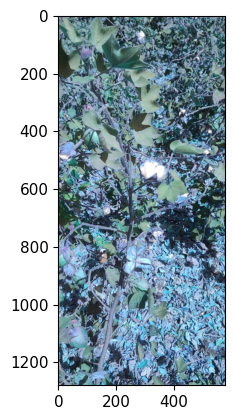

image 1/1: 1280x576 (no detections)
Speed: 3.0ms pre-process, 36.3ms inference, 1.0ms NMS per image at shape (1, 3, 640, 288)


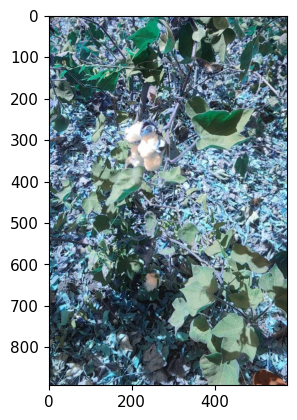

image 1/1: 892x576 (no detections)
Speed: 4.0ms pre-process, 98.7ms inference, 1.0ms NMS per image at shape (1, 3, 640, 416)


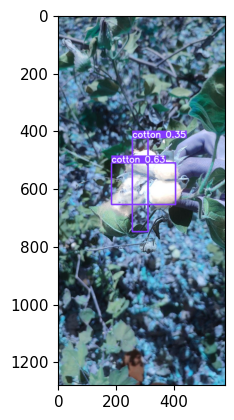

image 1/1: 1280x576 2 cottons
Speed: 2.0ms pre-process, 67.5ms inference, 4.0ms NMS per image at shape (1, 3, 640, 288)


In [8]:
# Define input and output directories
input_dir = 'Test Data\Images'
output_dir = 'Results\exp\Images'

# Create the output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Loop through all the images in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.jpg') or filename.endswith('.jpeg') or filename.endswith('.png'):
        # Read the input image
        img = cv2.imread(os.path.join(input_dir, filename))

        results = model(img)
        
        %matplotlib inline
        plt.imshow(np.squeeze(results.render()))
        plt.show()
        
        results.print()

        # Save the output image with the label as the filename in the output directory
        output_filename = f'{filename}.jpg'
        cv2.imwrite(os.path.join(output_dir, output_filename), img)